# DeepfakeFusionModel — Ghép Spatial + rPPG qua Cross-Attention Network (CAN)

**Lưu ý tên gọi:** "CAN" ở notebook nhánh rPPG là *Convolutional* Attention Network (kiến trúc nội
bộ DeepPhys). "CAN" ở notebook NÀY là **Cross-Attention Network** — module ghép 2 nhánh, khác
khái niệm, đừng nhầm khi viết vào báo cáo.

**Kết quả từng nhánh (đã train xong, dùng warm-start):**
| Nhánh | Accuracy | AUC | EER |
|---|---|---|---|
| Spatial (Swin Transformer) | 96.57% | 99.26% | 2.86% |
| rPPG (DeepPhys-CAN) | 88.43% | 94.30% | 14.82% |

**Quy trình đúng đã thống nhất trước đó — không phải "ghép file":**
1. Tạo `DeepfakeFusionModel` mới chứa: backbone Spatial (từ Swin đã train) + backbone rPPG (từ
   DeepPhysCAN đã train) + module Cross-Attention (**khởi tạo mới, chưa từng tồn tại**).
2. Load 2 checkpoint vào đúng submodule tương ứng (`load_state_dict`).
3. **Giai đoạn 1:** đóng băng cả 2 backbone, chỉ train Cross-Attention + classifier (module mới,
   bắt buộc phải train vì chưa học gì).
4. **Giai đoạn 2:** tinh chỉnh nhẹ toàn bộ (LR rất nhỏ), xem có cải thiện thêm không.

---
## 📋 Chuẩn bị Kaggle Input (4 mục — làm trước khi chạy)

| # | Dataset cần Add Input | Ghi chú |
|---|---|---|
| 1 | `thinhphan272/ffpp-c23-face-cache` | Cache ảnh cho Spatial (đã có) |
| 2 | `thinhphan272/ffpp-c23-rppg-cache` | Cache clip cho rPPG (đã có) |
| 3 | Checkpoint Spatial (`spatial_transformer_best.pth`) | **Đóng gói mới**: vào notebook Spatial đã Commit → tab Output → chọn file `.pth` → "Create Dataset from Output" |
| 4 | Checkpoint rPPG (`rppg_can_best.pth`) | Tương tự, từ notebook rPPG đã Commit |

Sau khi add xong, sửa lại 4 đường dẫn ở Mục 1 cho khớp tên dataset thật của bạn trên Kaggle.

**Về GPU:** Spatial dùng Swin-Base (87M tham số) khá nặng RAM — khuyến nghị chọn **GPU P100**
(nhiều VRAM hơn T4x2) trong Settings → Accelerator nếu có thể, hoặc giữ batch size nhỏ như cấu
hình mặc định dưới đây.

## 1. Cấu hình

In [1]:
import os, glob, time, random, copy, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA 4 ĐƯỜNG DẪN NÀY ====================
CACHE_DIR_SPATIAL = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"
CACHE_DIR_RPPG    = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
SPATIAL_CKPT_PATH = "/kaggle/input/datasets/thinhphan1506/dffusion-trained-pth/spatial_transformer/spatial_transformer_best.pth"
RPPG_CKPT_PATH    = "/kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/rppg_can_best.pth"

for p, name in [(CACHE_DIR_SPATIAL, "CACHE_DIR_SPATIAL"), (CACHE_DIR_RPPG, "CACHE_DIR_RPPG")]:
    assert os.path.isdir(p), f"Không tìm thấy {name}: {p} -- kiểm tra lại Add Input"
for p, name in [(SPATIAL_CKPT_PATH, "SPATIAL_CKPT_PATH"), (RPPG_CKPT_PATH, "RPPG_CKPT_PATH")]:
    assert os.path.exists(p), f"Không tìm thấy {name}: {p} -- kiểm tra lại tên dataset checkpoint đã tạo"

# ==================== THAM SỐ ====================
SPATIAL_BACKBONE_NAME = "swin_base_patch4_window7_224"
SPATIAL_IMG_SIZE = 224
N_SPATIAL_FRAMES_TRAIN = 4     # giảm so với 6 lúc train riêng -- tiết kiệm VRAM khi ghép cả 2 nhánh
N_SPATIAL_FRAMES_EVAL  = 8

CAN_IMG_SIZE = 72
RPPG_CLIP_LEN_TRAIN = 32
RPPG_CLIP_LEN_EVAL  = 64
DIFF_EPS = 1.0

FUSION_PROJ_DIM = 256
FUSION_HEADS = 4
DROPOUT = 0.2

BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4          # batch hiệu dụng ~16

EPOCHS_STAGE1 = 15             # đóng băng cả 2 backbone, chỉ train Cross-Attention
EPOCHS_STAGE2 = 10             # tinh chỉnh nhẹ toàn bộ
LR_FUSION = 5e-4
LR_FINETUNE_BACKBONE = 1e-6    # cực nhỏ khi tinh chỉnh backbone đã rất tốt
WEIGHT_DECAY = 1e-2

LABEL_SMOOTH_EPS = 0.05
EMA_DECAY = 0.999
PATIENCE = 8
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "/kaggle/working/fusion_model"
os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Device:", DEVICE)


Device: cuda


## 2. Đọc & đối chiếu 2 manifest (Spatial ∩ rPPG theo `video_id`)

2 cache được tạo độc lập nên cần join theo `video_id` để đảm bảo mỗi sample có đủ cả 2 loại dữ
liệu, đồng thời đối chiếu nhãn (`label`) giữa 2 manifest phải khớp nhau tuyệt đối.

In [2]:
def load_manifest(cache_dir, old_prefix):
    m = pd.read_csv(os.path.join(cache_dir, "manifest_processed.csv"))
    m["out_dir"] = m["out_dir"].astype(str).str.replace(old_prefix, cache_dir, regex=False)
    return m

manifest_spatial = load_manifest(CACHE_DIR_SPATIAL, "/kaggle/working/ffpp_c23_cache")
manifest_spatial = manifest_spatial[manifest_spatial["status"].isin(["ok", "skip_exists"])]

manifest_rppg = load_manifest(CACHE_DIR_RPPG, "/kaggle/working/ffpp_c23_rppg_cache")
manifest_rppg = manifest_rppg[
    manifest_rppg["status"].isin(["ok", "skip_exists", "partial"]) & (manifest_rppg["n_frames"] >= 50)
]

merged = manifest_spatial[["video_id", "split", "label", "method", "out_dir"]].rename(
    columns={"out_dir": "spatial_dir"}
).merge(
    manifest_rppg[["video_id", "out_dir", "label"]].rename(columns={"out_dir": "rppg_dir", "label": "label_rppg"}),
    on="video_id", how="inner"
)

label_mismatch = (merged["label"] != merged["label_rppg"]).sum()
assert label_mismatch == 0, f"CẢNH BÁO: {label_mismatch} video có nhãn KHÔNG khớp giữa 2 manifest -- dừng lại kiểm tra."
merged = merged.drop(columns=["label_rppg"])

print(f"Số video có đủ cả 2 loại cache: {len(merged)} / {len(manifest_spatial)} (spatial) / {len(manifest_rppg)} (rppg)")
print(merged.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0).rename(columns={0: "real", 1: "fake"}))

train_df = merged[merged.split == "train"].reset_index(drop=True)
val_df   = merged[merged.split == "val"].reset_index(drop=True)
test_df  = merged[merged.split == "test"].reset_index(drop=True)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Số video có đủ cả 2 loại cache: 17000 / 5000 (spatial) / 5000 (rppg)
label  real   fake
split             
test    140   2240
train   720  11520
val     140   2240

Train: 12240 | Val: 2380 | Test: 2380


## 3. Dataset ghép — mỗi sample trả về cả Spatial frames LẪN rPPG clip của cùng 1 video

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_spatial_frame(path, augment=False):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SPATIAL_IMG_SIZE, SPATIAL_IMG_SIZE))
    if augment and random.random() < 0.5:
        img = img[:, ::-1, :].copy()
    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1)).float()


def load_rppg_frame(path):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (CAN_IMG_SIZE, CAN_IMG_SIZE))
    return img.astype(np.float32)


def build_rppg_clip(frame_paths, clip_len):
    n_frames = len(frame_paths)
    need = clip_len + 1
    start = random.randint(0, max(n_frames - need, 0)) if n_frames >= need else 0
    appearances, motions, prev_img = [], [], None
    for i in range(min(need, n_frames)):
        fi = min(start + i, n_frames - 1)
        img = load_rppg_frame(frame_paths[fi])
        if prev_img is not None:
            appearances.append(img / 255.0)
            motions.append((img - prev_img) / (img + prev_img + DIFF_EPS))
        prev_img = img
    while len(appearances) < clip_len:
        appearances.append(appearances[-1] if appearances else np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), np.float32))
        motions.append(motions[-1] if motions else np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), np.float32))
    app = torch.from_numpy(np.stack(appearances[:clip_len])).permute(0, 3, 1, 2).float()
    mot = torch.from_numpy(np.stack(motions[:clip_len])).permute(0, 3, 1, 2).float()
    return app, mot


class FusionDataset(Dataset):
    """train=True: augment nhẹ + cắt ngẫu nhiên. train=False: cố định, dùng cho val/test."""
    def __init__(self, df, train=True):
        self.rows = df.reset_index(drop=True)
        self.train = train
        self.n_spatial = N_SPATIAL_FRAMES_TRAIN if train else N_SPATIAL_FRAMES_EVAL
        self.rppg_len = RPPG_CLIP_LEN_TRAIN if train else RPPG_CLIP_LEN_EVAL

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]

        spatial_files = sorted(glob.glob(os.path.join(row.spatial_dir, "*.jpg")))
        if self.train:
            chosen = random.sample(spatial_files, min(self.n_spatial, len(spatial_files)))
        else:
            step = max(len(spatial_files) // self.n_spatial, 1)
            chosen = spatial_files[::step][: self.n_spatial]
        while len(chosen) < self.n_spatial:
            chosen.append(chosen[-1] if chosen else spatial_files[0])
        spatial_frames = torch.stack([load_spatial_frame(p, augment=self.train) for p in chosen])

        rppg_files = sorted(glob.glob(os.path.join(row.rppg_dir, "*.jpg")))
        app_clip, mot_clip = build_rppg_clip(rppg_files, self.rppg_len)

        label = torch.tensor(row.label, dtype=torch.float32)
        if self.train:
            return spatial_frames, app_clip, mot_clip, label
        return spatial_frames, app_clip, mot_clip, label, row.video_id


train_ds = FusionDataset(train_df, train=True)
val_ds   = FusionDataset(val_df, train=False)
test_ds  = FusionDataset(test_df, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 12240 | Val: 2380 | Test: 2380


## 4. Nạp 2 backbone đã train sẵn (warm-start)

Định nghĩa lại đúng 2 kiến trúc gốc để `load_state_dict` khớp tên layer, sau đó chỉ giữ lại phần
backbone (bỏ classifier head cũ của từng nhánh — classifier mới sẽ nằm trong module Cross-Attention).

In [4]:
!pip install -q timm


In [5]:
import timm

# ---------- Backbone Spatial (Swin Transformer) ----------
class SpatialTransformerDetector(nn.Module):
    def __init__(self, backbone_name=SPATIAL_BACKBONE_NAME, pretrained=False, drop_path_rate=0.2):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0, drop_path_rate=drop_path_rate)
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Linear(feat_dim, 256), nn.GELU(), nn.Dropout(0.3), nn.Linear(256, 1),
        )
    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(-1)


spatial_full = SpatialTransformerDetector(pretrained=False)
ckpt_spatial = torch.load(SPATIAL_CKPT_PATH, map_location="cpu", weights_only=False)
spatial_full.load_state_dict(ckpt_spatial["model_state"])
spatial_backbone = spatial_full.backbone   # chỉ giữ backbone, bỏ classifier cũ
SPATIAL_EMBED_DIM = spatial_backbone.num_features
print(f"Đã nạp Spatial backbone (epoch={ckpt_spatial['epoch']}, val_auc={ckpt_spatial['val_metrics']['auc']:.4f}) "
      f"| embed_dim={SPATIAL_EMBED_DIM}")


# ---------- Backbone rPPG (DeepPhys-CAN) ----------
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                 nn.Linear(channels, channels // reduction), nn.ReLU(),
                                 nn.Linear(channels // reduction, channels), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                                   nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
    def forward(self, x):
        return self.se(self.conv(x))

class AttentionMask(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 1, kernel_size=1), nn.Sigmoid())
    def forward(self, x):
        return self.conv(x)

class TemporalAttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, dim // 4), nn.ReLU(), nn.Linear(dim // 4, 1))
    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1)

class DeepPhysCAN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.app_block1 = ConvBlock(3, 32); self.app_block2 = ConvBlock(32, 64); self.app_block3 = ConvBlock(64, 128, use_se=True)
        self.att_mask1 = AttentionMask(32); self.att_mask2 = AttentionMask(64); self.att_mask3 = AttentionMask(128)
        self.mot_block1 = ConvBlock(3, 32); self.mot_block2 = ConvBlock(32, 64); self.mot_block3 = ConvBlock(64, 128, use_se=True)
        self.pool = nn.AvgPool2d(2, 2); self.gap = nn.AdaptiveAvgPool2d(1)
        self.frame_feat = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Dropout(dropout))
        self.temporal_pool = TemporalAttentionPool(128)
        self.classifier = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
        self.embed_dim = 128

    def forward_single_pair(self, appearance, motion):
        a1 = self.app_block1(appearance); mask1 = self.att_mask1(a1); a1 = self.pool(a1)
        a2 = self.app_block2(a1); mask2 = self.att_mask2(a2); a2 = self.pool(a2)
        a3 = self.app_block3(a2); mask3 = self.att_mask3(a3)
        m1 = self.mot_block1(motion) * mask1; m1 = self.pool(m1)
        m2 = self.mot_block2(m1) * mask2; m2 = self.pool(m2)
        m3 = self.mot_block3(m2) * mask3
        feat = self.gap(m3).flatten(1)
        return self.frame_feat(feat)

    def forward_features(self, app_clip, mot_clip):
        B, T = app_clip.shape[:2]
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        frame_feats = self.forward_single_pair(app_flat, mot_flat).reshape(B, T, -1)
        return self.temporal_pool(frame_feats)


rppg_backbone = DeepPhysCAN()
ckpt_rppg = torch.load(RPPG_CKPT_PATH, map_location="cpu", weights_only=False)
rppg_backbone.load_state_dict(ckpt_rppg["model_state"])
RPPG_EMBED_DIM = rppg_backbone.embed_dim
print(f"Đã nạp rPPG backbone (epoch={ckpt_rppg['epoch']}, val_auc={ckpt_rppg['val_metrics']['auc']:.4f}) "
      f"| embed_dim={RPPG_EMBED_DIM}")


Đã nạp Spatial backbone (epoch=16, val_auc=0.9922) | embed_dim=1024
Đã nạp rPPG backbone (epoch=56, val_auc=0.9142) | embed_dim=128


## 5. Module Cross-Attention Network (CAN) ghép 2 nhánh + Fusion Model

Mỗi embedding (Spatial, rPPG) được coi như 1 "chuỗi độ dài 1", chiếu về cùng không gian, rồi
**Spatial hỏi rPPG** và **rPPG hỏi Spatial** qua Multi-Head Attention 2 chiều — kết quả nối lại
rồi qua classifier cuối.

In [6]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, spatial_dim, rppg_dim, proj_dim=FUSION_PROJ_DIM, n_heads=FUSION_HEADS, dropout=DROPOUT):
        super().__init__()
        self.spatial_proj = nn.Sequential(nn.Linear(spatial_dim, proj_dim), nn.LayerNorm(proj_dim))
        self.rppg_proj    = nn.Sequential(nn.Linear(rppg_dim, proj_dim), nn.LayerNorm(proj_dim))
        self.attn_s2r = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_r2s = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.classifier = nn.Sequential(
            nn.LayerNorm(proj_dim * 2), nn.Linear(proj_dim * 2, 128), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(128, 1),
        )

    def forward(self, spatial_embed, rppg_embed):
        s = self.spatial_proj(spatial_embed).unsqueeze(1)   # (B, 1, proj_dim)
        r = self.rppg_proj(rppg_embed).unsqueeze(1)          # (B, 1, proj_dim)
        s_att, _ = self.attn_s2r(query=s, key=r, value=r)    # Spatial "hỏi" rPPG
        r_att, _ = self.attn_r2s(query=r, key=s, value=s)    # rPPG "hỏi" Spatial
        fused = torch.cat([s_att.squeeze(1), r_att.squeeze(1)], dim=1)
        return self.classifier(fused).squeeze(-1)


class DeepfakeFusionModel(nn.Module):
    def __init__(self, spatial_backbone, rppg_backbone, spatial_dim, rppg_dim):
        super().__init__()
        self.spatial_backbone = spatial_backbone
        self.rppg_backbone = rppg_backbone
        self.fusion = CrossAttentionFusion(spatial_dim, rppg_dim)
        self.spatial_frozen = True
        self.rppg_frozen = True

    def set_trainable(self, spatial_trainable, rppg_trainable):
        for p in self.spatial_backbone.parameters():
            p.requires_grad = spatial_trainable
        for p in self.rppg_backbone.parameters():
            p.requires_grad = rppg_trainable
        self.spatial_frozen = not spatial_trainable
        self.rppg_frozen = not rppg_trainable

    def train(self, mode=True):
        super().train(mode)
        if self.spatial_frozen:
            self.spatial_backbone.eval()
        if self.rppg_frozen:
            self.rppg_backbone.eval()
        return self

    def encode_spatial(self, frames):     # frames: (B, N, 3, H, W)
        B, N = frames.shape[:2]
        flat = frames.reshape(B * N, *frames.shape[2:])
        ctx = torch.no_grad() if self.spatial_frozen else torch.enable_grad()
        with ctx:
            feats = self.spatial_backbone(flat)
        return feats.reshape(B, N, -1).mean(dim=1)

    def encode_rppg(self, app_clip, mot_clip):
        ctx = torch.no_grad() if self.rppg_frozen else torch.enable_grad()
        with ctx:
            return self.rppg_backbone.forward_features(app_clip, mot_clip)

    def forward(self, spatial_frames, app_clip, mot_clip):
        s_embed = self.encode_spatial(spatial_frames)
        r_embed = self.encode_rppg(app_clip, mot_clip)
        return self.fusion(s_embed, r_embed)


fusion_model = DeepfakeFusionModel(spatial_backbone, rppg_backbone, SPATIAL_EMBED_DIM, RPPG_EMBED_DIM).to(DEVICE)
fusion_model.set_trainable(spatial_trainable=False, rppg_trainable=False)
n_trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in fusion_model.parameters())
print(f"Tổng tham số: {n_total/1e6:.2f}M | Trainable (Giai đoạn 1 -- chỉ Cross-Attention): {n_trainable/1e6:.2f}M")


Tổng tham số: 88.25M | Trainable (Giai đoạn 1 -- chỉ Cross-Attention): 0.89M


## 6. Hàm tính metric (giữ nguyên chuẩn xuyên suốt đồ án)

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    acc_at_eer = accuracy_score(y_true, (y_score >= eer_thr).astype(int))
    return {"acc": acc, "auc": auc_val, "eer": eer, "far_at_0.5": far_05, "frr_at_0.5": frr_05,
            "cm_at_0.5": cm_05, "eer_threshold": eer_thr, "far_at_eer": far_eer,
            "frr_at_eer": frr_eer, "acc_at_eer": acc_at_eer}


## 7. Label Smoothing / EMA

In [8]:
def smooth_labels(labels, eps=LABEL_SMOOTH_EPS):
    return labels * (1 - eps) + 0.5 * eps


class ModelEma:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema_model = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema_model.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, ema_v in self.ema_model.state_dict().items():
            model_v = msd[k].detach()
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(model_v, alpha=1 - self.decay)
            else:
                ema_v.copy_(model_v)


## 8. Vòng lặp huấn luyện — 2 giai đoạn

- **Giai đoạn 1:** đóng băng cả 2 backbone, chỉ train Cross-Attention + classifier.
- **Giai đoạn 2:** mở khoá tinh chỉnh nhẹ toàn bộ (LR cực nhỏ cho backbone) — xem có cải thiện
  thêm không so với chỉ dừng ở Giai đoạn 1.

In [9]:
@torch.no_grad()
def evaluate(eval_model, loader, criterion):
    eval_model.eval()
    y_true, y_score, losses = [], [], []
    for sp_frames, app_clip, mot_clip, label, _vid in loader:
        sp_frames, app_clip, mot_clip = sp_frames.to(DEVICE), app_clip.to(DEVICE), mot_clip.to(DEVICE)
        label = label.to(DEVICE)
        logits = eval_model(sp_frames, app_clip, mot_clip)
        losses.append(criterion(logits, label).item())
        y_score.append(torch.sigmoid(logits).item())
        y_true.append(label.item())
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    return metrics


criterion = nn.BCEWithLogitsLoss()
ema = ModelEma(fusion_model, decay=EMA_DECAY)

BEST_PATH = os.path.join(OUT_DIR, "fusion_model_best.pth")
history = {"stage": [], "epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "val_eer": [], "used_ema": []}
best_val_auc = -1
patience_ctr = 0
global_epoch = 0

for stage, n_epochs, spatial_tr, rppg_tr, lr_fusion, lr_backbone in [
    ("stage1_freeze",   EPOCHS_STAGE1, False, False, LR_FUSION, 0.0),
    ("stage2_finetune", EPOCHS_STAGE2, True,  True,  LR_FUSION, LR_FINETUNE_BACKBONE),
]:
    fusion_model.set_trainable(spatial_trainable=spatial_tr, rppg_trainable=rppg_tr)
    n_trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
    print(f"\n=== {stage} ({n_epochs} epoch) | trainable params: {n_trainable/1e6:.2f}M ===")

    optimizer = torch.optim.AdamW([
        {"params": fusion_model.fusion.parameters(), "lr": lr_fusion},
        {"params": fusion_model.spatial_backbone.parameters(), "lr": lr_backbone},
        {"params": fusion_model.rppg_backbone.parameters(), "lr": lr_backbone},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs * len(train_loader))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    for epoch in range(1, n_epochs + 1):
        global_epoch += 1
        fusion_model.train()
        running_loss, n_batches = 0.0, 0
        t0 = time.time()
        optimizer.zero_grad()

        for step, (sp_frames, app_clip, mot_clip, label) in enumerate(train_loader):
            sp_frames, app_clip, mot_clip = sp_frames.to(DEVICE), app_clip.to(DEVICE), mot_clip.to(DEVICE)
            label = smooth_labels(label.to(DEVICE))

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = fusion_model(sp_frames, app_clip, mot_clip)
                loss = criterion(logits, label) / GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                ema.update(fusion_model)

            running_loss += loss.item() * GRAD_ACCUM_STEPS
            n_batches += 1

        train_loss = running_loss / max(n_batches, 1)
        val_metrics_raw = evaluate(fusion_model, val_loader, criterion)
        val_metrics_ema = evaluate(ema.ema_model, val_loader, criterion)
        use_ema = val_metrics_ema["auc"] >= val_metrics_raw["auc"]
        val_metrics = val_metrics_ema if use_ema else val_metrics_raw

        history["stage"].append(stage); history["epoch"].append(global_epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"]); history["val_auc"].append(val_metrics["auc"])
        history["val_eer"].append(val_metrics["eer"]); history["used_ema"].append(use_ema)

        dt = time.time() - t0
        print(f"[{stage} {epoch:02d}/{n_epochs}] train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} "
              f"val_acc={val_metrics['acc']:.4f} val_auc={val_metrics['auc']:.4f} val_eer={val_metrics['eer']:.4f} "
              f"| {'EMA' if use_ema else 'raw'} | {dt:.1f}s")

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]; patience_ctr = 0
            save_state = ema.ema_model.state_dict() if use_ema else fusion_model.state_dict()
            torch.save({"model_state": save_state, "epoch": global_epoch, "stage": stage,
                        "used_ema": use_ema, "val_metrics": val_metrics,
                        "spatial_embed_dim": SPATIAL_EMBED_DIM, "rppg_embed_dim": RPPG_EMBED_DIM}, BEST_PATH)
            print(f"    -> Lưu checkpoint tốt nhất (val_auc={best_val_auc:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"Early stopping tại epoch {global_epoch}")
                break

pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)



=== stage1_freeze (15 epoch) | trainable params: 0.89M ===
[stage1_freeze 01/15] train_loss=0.1282 val_loss=0.0925 val_acc=0.9752 val_auc=0.9931 val_eer=0.0357 | EMA | 2850.9s
    -> Lưu checkpoint tốt nhất (val_auc=0.9931)
[stage1_freeze 02/15] train_loss=0.1245 val_loss=0.0936 val_acc=0.9756 val_auc=0.9928 val_eer=0.0366 | EMA | 2013.1s
[stage1_freeze 03/15] train_loss=0.1238 val_loss=0.0953 val_acc=0.9761 val_auc=0.9940 val_eer=0.0348 | raw | 1832.3s
    -> Lưu checkpoint tốt nhất (val_auc=0.9940)
[stage1_freeze 04/15] train_loss=0.1237 val_loss=0.0935 val_acc=0.9756 val_auc=0.9924 val_eer=0.0357 | EMA | 1539.4s
[stage1_freeze 05/15] train_loss=0.1228 val_loss=0.0989 val_acc=0.9756 val_auc=0.9922 val_eer=0.0357 | EMA | 1494.1s
[stage1_freeze 06/15] train_loss=0.1226 val_loss=0.1061 val_acc=0.9744 val_auc=0.9917 val_eer=0.0402 | raw | 1459.8s
[stage1_freeze 07/15] train_loss=0.1231 val_loss=0.0950 val_acc=0.9777 val_auc=0.9926 val_eer=0.0375 | raw | 1418.9s
[stage1_freeze 08/15] tra

## 9. Đánh giá test + Breakdown theo phương pháp fake + So sánh với từng nhánh riêng

In [10]:
@torch.no_grad()
def evaluate_with_tta(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score = [], []
    for sp_frames, app_clip, mot_clip, label, vid in loader:
        sp_frames, app_clip, mot_clip = sp_frames.to(DEVICE), app_clip.to(DEVICE), mot_clip.to(DEVICE)
        logits_list = [eval_model(sp_frames, app_clip, mot_clip)]
        if use_tta:
            logits_list.append(eval_model(torch.flip(sp_frames, dims=[4]),
                                           torch.flip(app_clip, dims=[4]), torch.flip(mot_clip, dims=[4])))
        probs = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(probs.item()); y_true.append(label.item())
    return np.array(y_true), np.array(y_score)


ckpt_fusion = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
fusion_model.load_state_dict(ckpt_fusion["model_state"])
print(f"Nạp checkpoint fusion tốt nhất: epoch={ckpt_fusion['epoch']} stage={ckpt_fusion['stage']} "
      f"(val_auc={ckpt_fusion['val_metrics']['auc']:.4f})")

y_true, y_score = evaluate_with_tta(fusion_model, test_loader, use_tta=True)
test_metrics = calc_metrics(y_true, y_score)

print("\n=== KẾT QUẢ TEST (intra-FF++ C23) — DeepfakeFusionModel (Spatial + rPPG qua CAN) ===")
print(f"Accuracy: {test_metrics['acc']*100:.2f}% | AUC: {test_metrics['auc']*100:.2f}% | EER: {test_metrics['eer']*100:.2f}%")

test_df_ordered = test_df.reset_index(drop=True)
breakdown_rows = []
real_mask = test_df_ordered["label"].values == 0
for method in sorted(test_df_ordered.loc[~real_mask, "method"].unique()):
    method_mask = (test_df_ordered["method"].values == method)
    sel = real_mask | method_mask
    m = calc_metrics(y_true[sel], y_score[sel])
    breakdown_rows.append({"method": method, "auc": m["auc"], "eer": m["eer"]})
breakdown_df = pd.DataFrame(breakdown_rows).sort_values("auc")
breakdown_df.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)

print("\n=== Bảng A (ablation kiến trúc) -- so sánh với từng nhánh riêng lẻ ===")
comparison = pd.DataFrame([
    {"model": "A1 - Spatial only",       "acc": 0.9657, "auc": 0.9926, "eer": 0.0286},
    {"model": "A2 - rPPG only",          "acc": 0.8843, "auc": 0.9430, "eer": 0.1482},
    {"model": "A4 - Fusion (đề xuất)",   "acc": test_metrics["acc"], "auc": test_metrics["auc"], "eer": test_metrics["eer"]},
])
print(comparison.to_string(index=False))
comparison.to_csv(os.path.join(OUT_DIR, "ablation_table_A.csv"), index=False)

print("\n=== Breakdown theo method ===")
print(breakdown_df.to_string(index=False))

result_row = {"model": "DeepfakeFusionModel_CrossAttention", "acc_intra": test_metrics["acc"],
              "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
              "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"]}
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)


Nạp checkpoint fusion tốt nhất: epoch=8 stage=stage1_freeze (val_auc=0.9942)

=== KẾT QUẢ TEST (intra-FF++ C23) — DeepfakeFusionModel (Spatial + rPPG qua CAN) ===
Accuracy: 98.19% | AUC: 99.09% | EER: 2.86%

=== Bảng A (ablation kiến trúc) -- so sánh với từng nhánh riêng lẻ ===
                model      acc      auc      eer
    A1 - Spatial only 0.965700 0.992600 0.028600
       A2 - rPPG only 0.884300 0.943000 0.148200
A4 - Fusion (đề xuất) 0.981933 0.990871 0.028571

=== Breakdown theo method ===
        method      auc      eer
NeuralTextures 0.985740 0.050000
     Face2Face 0.989630 0.021429
      FaceSwap 0.993304 0.023214
     Deepfakes 0.994809 0.014286


## 10. Vẽ đường cong huấn luyện

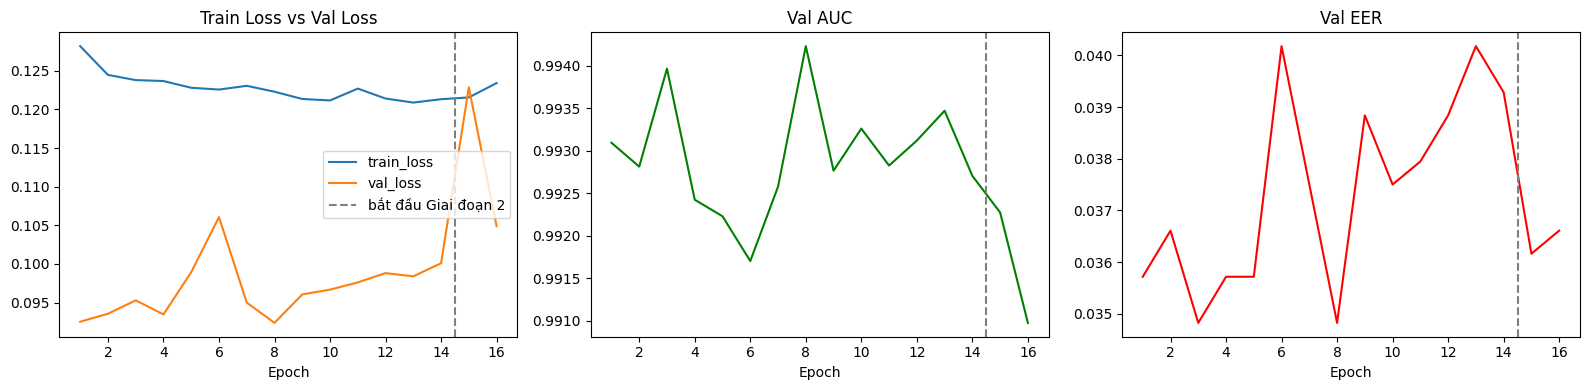

In [11]:
import matplotlib.pyplot as plt

hist_df = pd.read_csv(os.path.join(OUT_DIR, "train_history.csv"))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
axes[0].axvline(EPOCHS_STAGE1 - 0.5, color="gray", linestyle="--", label="bắt đầu Giai đoạn 2")
axes[0].set_title("Train Loss vs Val Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="green")
axes[1].axvline(EPOCHS_STAGE1 - 0.5, color="gray", linestyle="--")
axes[1].set_title("Val AUC"); axes[1].set_xlabel("Epoch")
axes[2].plot(hist_df["epoch"], hist_df["val_eer"], color="red")
axes[2].axvline(EPOCHS_STAGE1 - 0.5, color="gray", linestyle="--")
axes[2].set_title("Val EER"); axes[2].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=100)
plt.show()


## 11. ⚠️ Lưu kết quả & bước tiếp theo

**Save Version → Save & Run All (Commit)** → Output → New Dataset, lưu:
- `fusion_model_best.pth`, `train_history.csv`, `test_results_intra.csv`,
  `auc_breakdown_by_method.csv`, `ablation_table_A.csv`, `training_curves.png`

**Bước tiếp theo (chưa làm trong notebook này):**
1. **Đánh giá cross-dataset trên Celeb-DF v2** — đúng mục tiêu cuối cùng đã đặt ra, nhưng cần
   **xây cache Celeb-DF v2 trước** (chưa có trong đồ án — cần 1 notebook chuẩn bị dữ liệu tương tự
   `prepare-data-rppg`/cache Spatial nhưng cho Celeb-DF v2). Báo tôi nếu muốn làm bước này tiếp.
2. Dùng `ablation_table_A.csv` + `auc_breakdown_by_method.csv` để viết phần ablation trong Chương 3.
3. So sánh `test_results_intra.csv` của fusion với 4 baseline (Xception/SBI/UCF/Wu et al.) đã train
   trước đó để hoàn thiện bảng so sánh chính.